# Stable Video Diffusion with Perceptual Trajectory Guidance

This notebook implements perceptual trajectory smoothing and ensemble techniques for Stable Video Diffusion (SVD).

In [11]:
# ==========================================
# CELL 1: Configuration and Imports
# ==========================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import GaussianBlur
import matplotlib.pyplot as plt

CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float16,
    "num_frames": 14,
    "fps": 2,
    "height": 320,
    "width": 576,
    "run_standard_psg": True,
    "run_strong_straightening": False,
    "run_kernel_regression": True,
    "kernel_degrees": [2, 3, 4, 5],
    "run_mpes_ensemble": True,
    "ensemble_paths": 3,
    "save_dir": "./experiment-results"
}

os.makedirs(CONFIG["save_dir"], exist_ok=True)
for sub in ["videos", "trajectories", "plots"]:
    os.makedirs(os.path.join(CONFIG["save_dir"], sub), exist_ok=True)

# Read HF token
with open("hf-access-token.txt", "r") as f:
    hf_token = f.read().strip()

print("Setup Complete. Config initialized.")

Setup Complete. Config initialized.


In [ ]:
# ==========================================
# CELL 2: Lightweight V1 Perceptual Space
# ==========================================

class V1PerceptualSpace(nn.Module):
    def __init__(self):
        super().__init__()
        self.filters = nn.Conv2d(3, 12, kernel_size=15, padding=7, bias=False, groups=3)
        self.filters.weight.requires_grad = False
        nn.init.normal_(self.filters.weight, std=0.1)
        self.retina_blur = GaussianBlur(kernel_size=5, sigma=1.0)
        
    def forward(self, x):
        blurred = self.retina_blur(x)
        retina_out = x - blurred
        v1_response = F.relu(self.filters(retina_out))
        return F.adaptive_avg_pool2d(v1_response, (1, 1)).view(x.size(0), -1)

v1_space = V1PerceptualSpace().to(CONFIG["device"], CONFIG["dtype"])

In [13]:
# ==========================================
# CELL 3: Core Trajectory & Constraint Methods (PRECISION FIXED)
# ==========================================

def calculate_curvature_loss(v1_features):
    displacements = v1_features[1:] - v1_features[:-1]
    disp_norm = F.normalize(displacements, p=2, dim=1)
    cos_sim = torch.sum(disp_norm[:-1] * disp_norm[1:], dim=1)
    cos_sim = torch.clamp(cos_sim, -1.0 + 1e-7, 1.0 - 1e-7)
    curvature = torch.acos(cos_sim)
    return curvature.mean()

def apply_strong_straightening(latent_seq):
    N = latent_seq.shape[0]
    start_frame = latent_seq[0]
    end_frame = latent_seq[-1]
    linearized = torch.zeros_like(latent_seq)
    for i in range(N):
        alpha = i / (N - 1)
        linearized[i] = (1 - alpha) * start_frame + alpha * end_frame
    return linearized

def kernel_trajectory_regression(latent_seq, parameters=3):
    N = latent_seq.shape[0]
    
    # FIX: Force 't' and 'A' to use float32 for numerical stability
    t = torch.linspace(0, 1, N, device=latent_seq.device, dtype=torch.float32).unsqueeze(1)
    A = torch.cat([t**i for i in range(parameters)], dim=1)
    
    # FIX: Temporarily cast the latent sequence to float32
    flat_seq = latent_seq.reshape(N, -1).to(torch.float32)
    
    # Matrix inversion is now safely performed in float32
    A_T = A.t()
    pseudo_inv = torch.inverse(A_T @ A) @ A_T
    coeffs = pseudo_inv @ flat_seq
    smoothed_flat = A @ coeffs
    
    # FIX: Cast the result back to fp16 (latent_seq.dtype) before returning
    return smoothed_flat.reshape(latent_seq.shape).to(latent_seq.dtype)

In [14]:
# ==========================================
# CELL 4: Pipeline Hook for Inference
# ==========================================

def perceptual_guidance_step_callback(_pipeline, step_index, _timestep, callback_kwargs):
    _ = (_pipeline, _timestep)
    latents = callback_kwargs["latents"]
    seq = latents[0].permute(1, 0, 2, 3)

    if CONFIG["run_strong_straightening"] and step_index % 5 == 0:
        seq = apply_strong_straightening(seq)

    if CONFIG["run_kernel_regression"] and step_index % 5 == 0:
        seq = kernel_trajectory_regression(seq, parameters=3)

    latents[0] = seq.permute(1, 0, 2, 3)
    callback_kwargs["latents"] = latents
    return callback_kwargs

In [15]:
# ==========================================
# CELL 5: The Two-Step Text-to-Video Pipeline (With A/B Comparison)
# ==========================================
import gc
from typing import Any, cast

import torch
from diffusers.pipelines.stable_diffusion_xl.pipeline_stable_diffusion_xl import StableDiffusionXLPipeline
from diffusers.pipelines.stable_video_diffusion.pipeline_stable_video_diffusion import StableVideoDiffusionPipeline
from diffusers.utils.export_utils import export_to_gif

# Define your text prompt here - added "mid-stride" to force motion in the starting frame
TEXT_PROMPT = "Action shot, motion blur, a futuristic cyberpunk robot mid-stride walking down a neon-lit street, 8k resolution, photorealistic"

# ---------------------------------------------------------
# PHASE 1: TEXT TO IMAGE (SDXL)
# ---------------------------------------------------------
print("Phase 1: Loading SDXL...")

# 1. Nuke any lingering memory before we start
gc.collect()
torch.cuda.empty_cache()

t2i_pipeline = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)
# Offloads SDXL layers back to RAM immediately after they are used
t2i_pipeline.enable_model_cpu_offload()

print(f"Generating starting frame for prompt: '{TEXT_PROMPT}'")
t2i_result = t2i_pipeline(
    prompt=TEXT_PROMPT,
    num_inference_steps=25,
    height=576,
    width=1024
)
generated_image = cast(Any, t2i_result).images[0]

generated_image.save(f"{CONFIG['save_dir']}/starting_frame.png")
print("Starting frame generated and saved!")

# ---------------------------------------------------------
# THE MEMORY AIRLOCK (CRITICAL FOR RTX 4060)
# ---------------------------------------------------------
print("Purging SDXL from memory...")
del t2i_pipeline
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Resize the pristine SDXL image down to our safe SVD resolution
input_img_pil = generated_image.resize((CONFIG["width"], CONFIG["height"]))

# ---------------------------------------------------------
# PHASE 2: IMAGE TO VIDEO (SVD with Perceptual Straightening)
# ---------------------------------------------------------
print("Phase 2: Loading Stable Video Diffusion...")

svd_pipeline = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid",
    torch_dtype=CONFIG["dtype"],
    variant="fp16",
    use_safetensors=True,
    token=hf_token
)

# Maximum VRAM conservation for the video generation
svd_pipeline.enable_sequential_cpu_offload()

try:
    svd_pipeline.enable_xformers_memory_efficient_attention()
except Exception:
    pass # Falls back to PyTorch native SDPA

# --- GENERATION 1: BASELINE (NO STRAIGHTENING) ---
print("Generating Base Video (No Guidance)...")
base_result = svd_pipeline(
    input_img_pil,
    decode_chunk_size=1,
    generator=torch.manual_seed(42),
    motion_bucket_id=127,
    noise_aug_strength=0.02,
    num_frames=CONFIG["num_frames"]
)
base_out = cast(Any, base_result).frames[0]

export_to_gif(cast(Any, base_out), f"{CONFIG['save_dir']}/videos/base_video.gif")
print("Base video saved!")

Phase 1: Loading SDXL...


Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  4.43it/s]


Generating starting frame for prompt: 'Action shot, motion blur, a futuristic cyberpunk robot mid-stride walking down a neon-lit street, 8k resolution, photorealistic'


100%|██████████| 25/25 [00:19<00:00,  1.30it/s]


Starting frame generated and saved!
Purging SDXL from memory...
Phase 2: Loading Stable Video Diffusion...


Loading pipeline components...: 100%|██████████| 5/5 [00:01<00:00,  4.13it/s]


Generating Base Video (No Guidance)...


100%|██████████| 25/25 [03:45<00:00,  9.00s/it]


Base video saved!


In [16]:
# --- GENERATION 2: GUIDED (PERCEPTUAL STRAIGHTENING) ---
print("Generating Guided Video with Perceptual Straightening...")
guided_result = svd_pipeline(
    input_img_pil,
    decode_chunk_size=1,
    generator=torch.manual_seed(42), # Exact same seed to guarantee same initial noise
    motion_bucket_id=127,            # Exact same motion bucket
    noise_aug_strength=0.02,
    callback_on_step_end=cast(Any, perceptual_guidance_step_callback), # <--- The intervention
    callback_on_step_end_tensor_inputs=["latents"],
    num_frames=CONFIG["num_frames"]
)
guided_out = cast(Any, guided_result).frames[0]

export_to_gif(cast(Any, guided_out), f"{CONFIG['save_dir']}/videos/text_to_guided_video.gif")
print("Success! Both videos generated for comparison.")

Generating Guided Video with Perceptual Straightening...


100%|██████████| 25/25 [03:42<00:00,  8.89s/it]


Success! Both videos generated for comparison.


In [17]:
# ==========================================
# CELL 6: Multi-Path Ensemble Sampling (MPES)
# ==========================================
import numpy as np
import torch


def mpes_generation(image, paths=3):
    print(f"Running MPES with {paths} paths...")
    all_latents = []
    for i in range(paths):
        out_result = svd_pipeline(
            image,
            decode_chunk_size=1,
            generator=torch.manual_seed(42 + i),
            output_type="latent",
            num_frames=CONFIG["num_frames"]
        )
        out = cast(Any, out_result).frames
        all_latents.append(out)

    # Average in latent space
    avg_latents = cast(Any, sum(all_latents) / paths)

    print("Decoding averaged latents...")
    decoded_frames = []
    for i in range(CONFIG["num_frames"]):
        # FIX: Select exactly index 'i' instead of slicing 'i:i+1'.
        # This turns the 5D tensor into the 4D tensor [1, 4, H, W] the VAE expects.
        frame_latent = avg_latents[:, i, :, :, :]

        with torch.no_grad():
            frame_pixel = svd_pipeline.vae.decode(
                frame_latent / svd_pipeline.vae.config.scaling_factor,
                num_frames=1
            ).sample

        # Post-process tensor to PIL
        frame_pixel = (frame_pixel / 2 + 0.5).clamp(0, 1)
        frame_pixel = frame_pixel.cpu().permute(0, 2, 3, 1).float().numpy()
        from PIL import Image
        frame_pil = Image.fromarray((frame_pixel[0] * 255).astype(np.uint8))
        decoded_frames.append(frame_pil)

    return decoded_frames


if CONFIG["run_mpes_ensemble"]:
    mpes_out = mpes_generation(input_img_pil, paths=CONFIG["ensemble_paths"])
    export_to_gif(cast(Any, mpes_out), f"{CONFIG['save_dir']}/videos/mpes_video.gif")
    print("MPES video generated and saved!")

Running MPES with 3 paths...


100%|██████████| 25/25 [03:43<00:00,  8.94s/it]


Decoding averaged latents...
MPES video generated and saved!


Base Trajectory Curvature: 1.6602
Guided Trajectory Curvature: 1.2607


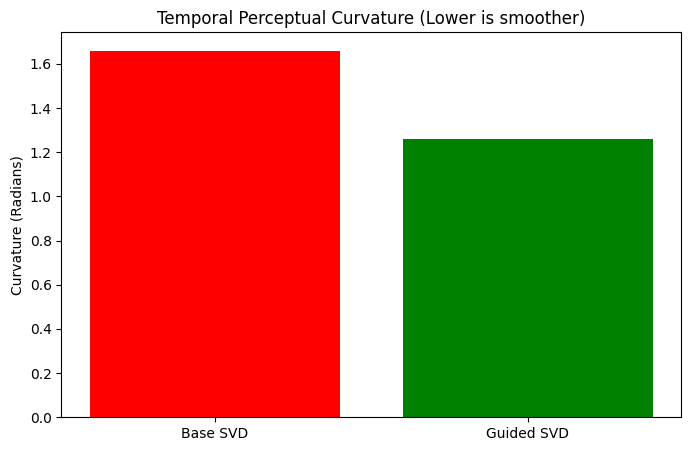

In [18]:
# ==========================================
# CELL 7: Evaluation Metrics & Plotting
# ==========================================

def compute_temporal_consistency_metric(video_frames_list):
    import torchvision.transforms as T
    transform = T.Compose([T.ToTensor(), T.Resize((128, 128))])

    tensors = torch.stack([transform(f) for f in video_frames_list]).to(
        CONFIG["device"], CONFIG["dtype"]
    )

    with torch.no_grad():
        v1_feats = v1_space(tensors)
        curvature = calculate_curvature_loss(v1_feats)
    return curvature.item()

base_curv = compute_temporal_consistency_metric(base_out)
guided_curv = compute_temporal_consistency_metric(guided_out)

print(f"Base Trajectory Curvature: {base_curv:.4f}")
print(f"Guided Trajectory Curvature: {guided_curv:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(['Base SVD', 'Guided SVD'], [base_curv, guided_curv], color=['red', 'green'])
plt.title('Temporal Perceptual Curvature (Lower is smoother)')
plt.ylabel('Curvature (Radians)')
plt.savefig(f"{CONFIG['save_dir']}/plots/curvature_comparison.png")
plt.show()

In [19]:
# ==========================================
# CELL 7: Kernel Regression Degree Experiment
# ==========================================
import os
import gc
from typing import Any, cast

import torch
from diffusers.utils.export_utils import export_to_gif

# 1. Setup the dedicated subfolder
kernel_save_dir = os.path.join(CONFIG["save_dir"], "videos", "kernel_degrees")
os.makedirs(kernel_save_dir, exist_ok=True)
print(f"Saving regression experiments to: {kernel_save_dir}")

# 2. The Callback Factory
# This dynamically builds a callback function for the specific polynomial degree
def get_dynamic_regression_callback(degree):
    def dynamic_callback(_pipe, step_index, _timestep, callback_kwargs):
        _ = (_pipe, _timestep)
        latents = callback_kwargs["latents"]
        # Extract temporal sequence: [F, C, H, W]
        seq = latents[0].permute(1, 0, 2, 3)

        # Apply the smoothing filter every 5 steps
        if step_index % 5 == 0:
            seq = kernel_trajectory_regression(seq, parameters=degree)

        latents[0] = seq.permute(1, 0, 2, 3)
        callback_kwargs["latents"] = latents
        return callback_kwargs
    return dynamic_callback

# 3. Run the Experiment Loop
degrees_to_test = [2, 3, 4, 5]

for deg in degrees_to_test:
    print(f"\n--- Generating Video with {deg}-Parameter Kernel Regression ---")

    # Optional: Brief explanation of what the math is doing
    if deg == 2:
        print("    (Degree 2 = Pure Linear Trajectory. Expected: Highly restricted motion)")
    elif deg == 3:
        print("    (Degree 3 = Quadratic Trajectory. Expected: Smooth acceleration/deceleration)")
    elif deg == 5:
        print("    (Degree 5 = Quartic Trajectory. Expected: Allows complex motion but filters micro-jitters)")

    # Generate the video
    deg_result = svd_pipeline(
        input_img_pil, # Uses the exact same starting frame from SDXL
        decode_chunk_size=1, # Mandatory VRAM protection
        generator=torch.manual_seed(42), # Lock seed for true A/B/C/D comparison
        motion_bucket_id=127,
        noise_aug_strength=0.02,
        callback_on_step_end=cast(Any, get_dynamic_regression_callback(deg)),
        callback_on_step_end_tensor_inputs=["latents"],
        num_frames=CONFIG["num_frames"]
    )
    deg_out = cast(Any, deg_result).frames[0]

    # Save the output
    save_path = os.path.join(kernel_save_dir, f"regression_degree_{deg}.gif")
    export_to_gif(cast(Any, deg_out), save_path)
    print(f"Saved: {save_path}")

    # 4. Mandatory VRAM Purge between runs
    # Even with sequential offload, intermediate tensors can build up in the cache
    del deg_out
    gc.collect()
    torch.cuda.empty_cache()

print("\nExperiment Complete! You can now compare the GIFs side-by-side.")

Saving regression experiments to: ./experiment-results\videos\kernel_degrees

--- Generating Video with 2-Parameter Kernel Regression ---
    (Degree 2 = Pure Linear Trajectory. Expected: Highly restricted motion)


100%|██████████| 25/25 [03:42<00:00,  8.90s/it]


Saved: ./experiment-results\videos\kernel_degrees\regression_degree_2.gif

--- Generating Video with 3-Parameter Kernel Regression ---
    (Degree 3 = Quadratic Trajectory. Expected: Smooth acceleration/deceleration)


100%|██████████| 25/25 [03:41<00:00,  8.85s/it]


Saved: ./experiment-results\videos\kernel_degrees\regression_degree_3.gif

--- Generating Video with 4-Parameter Kernel Regression ---


100%|██████████| 25/25 [03:36<00:00,  8.66s/it]


Saved: ./experiment-results\videos\kernel_degrees\regression_degree_4.gif

--- Generating Video with 5-Parameter Kernel Regression ---
    (Degree 5 = Quartic Trajectory. Expected: Allows complex motion but filters micro-jitters)


100%|██████████| 25/25 [03:34<00:00,  8.59s/it]


Saved: ./experiment-results\videos\kernel_degrees\regression_degree_5.gif

Experiment Complete! You can now compare the GIFs side-by-side.


## Additional Evaluation Metrics and Comparison Plots

This section adds:
- Temporal metrics from hypothesis_testing.ipynb: SSIM (higher is better) and PTD (lower is better)
- Trajectory comparison plots inspired by doing_it_right.ipynb using 2D PCA-style projection and straightness scores


Method metrics (Hypothesis-Testing style):
Method                      SSIM       PTD    Straight
baseline                  0.7104    12.389      0.9326
guided                    0.7000    13.181      0.6037
mpes                      0.7524     9.429      0.9483
degree_2                  0.7597    11.022      0.9390
degree_3                  0.7000    13.181      0.6037
degree_4                  0.7097    12.420      0.9313
degree_5                  0.6677    14.823      0.9256


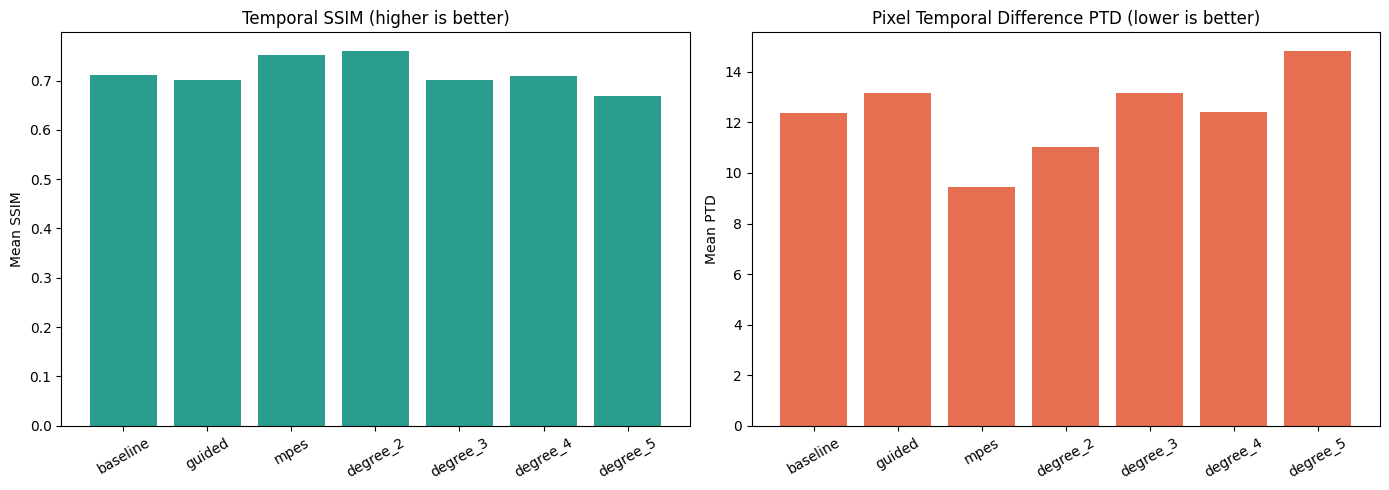

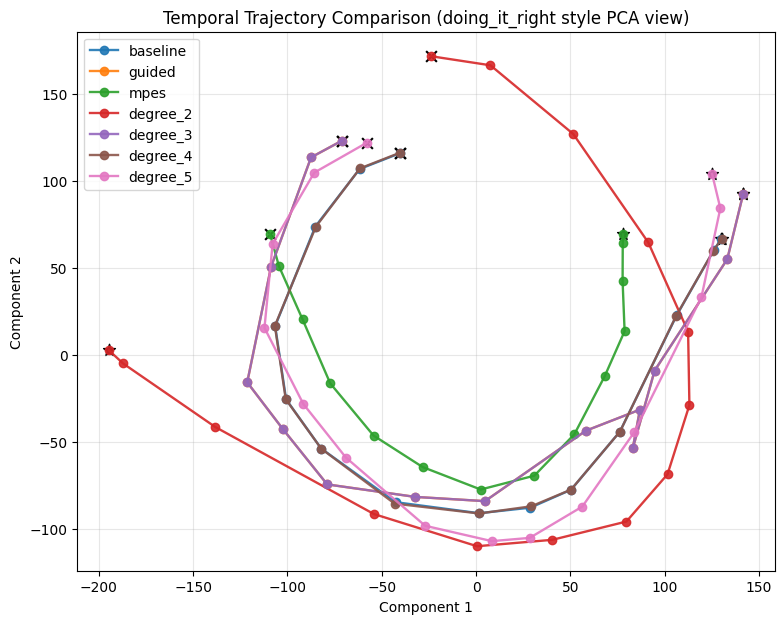


Saved metrics JSON: ./experiment-results\metadata\additional_eval_metrics_sushi.json
Saved metrics plot: ./experiment-results\plots\additional_metrics_comparison_sushi.png
Saved trajectory plot: ./experiment-results\plots\additional_trajectory_comparison_sushi.png


In [20]:
# ==========================================
# Additional Metrics + Comparison Plots
# ==========================================
import glob
import importlib
import json
import os

np = importlib.import_module("numpy")
plt = importlib.import_module("matplotlib.pyplot")


def read_gif_frames(gif_path: str):
    pil_image = importlib.import_module("PIL.Image")
    pil_sequence = importlib.import_module("PIL.ImageSequence")
    with pil_image.open(gif_path) as img:
        return [frame.convert("RGB").copy() for frame in pil_sequence.Iterator(img)]


def pca_2d(features):
    centered = features - features.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    return centered @ vh[:2].T


def calculate_straightness(trajectory):
    if len(trajectory) < 3:
        return 0.0
    deltas = trajectory[1:] - trajectory[:-1]
    norms = np.linalg.norm(deltas, axis=1, keepdims=True)
    deltas_norm = deltas / (norms + 1e-8)
    cos_sims = np.sum(deltas_norm[:-1] * deltas_norm[1:], axis=1)
    return float(np.mean(cos_sims))


def _load_optional_ssim_callable():
    try:
        metrics_mod = importlib.import_module("skimage.metrics")
        return getattr(metrics_mod, "structural_similarity", None)
    except Exception:
        return None


def _simple_ssim_rgb(a, b) -> float:
    # Fallback global SSIM approximation if skimage is unavailable.
    if a.ndim == 3:
        a_gray = 0.2989 * a[..., 0] + 0.5870 * a[..., 1] + 0.1140 * a[..., 2]
        b_gray = 0.2989 * b[..., 0] + 0.5870 * b[..., 1] + 0.1140 * b[..., 2]
    else:
        a_gray = a
        b_gray = b

    mu_a = float(np.mean(a_gray))
    mu_b = float(np.mean(b_gray))
    var_a = float(np.var(a_gray))
    var_b = float(np.var(b_gray))
    cov_ab = float(np.mean((a_gray - mu_a) * (b_gray - mu_b)))

    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    num = (2.0 * mu_a * mu_b + c1) * (2.0 * cov_ab + c2)
    den = (mu_a ** 2 + mu_b ** 2 + c1) * (var_a + var_b + c2) + 1e-12
    return float(num / den)


def _num(value) -> float:
    try:
        return np.asarray(value, dtype=np.float64).item()
    except Exception:
        return float("nan")


def compute_temporal_metrics(frames):
    frames_np = [np.asarray(frame).astype(np.float32) / 255.0 for frame in frames]
    ssim_callable = _load_optional_ssim_callable()

    ssim_vals = []
    ptd_vals = []
    for i in range(len(frames_np) - 1):
        a = frames_np[i]
        b = frames_np[i + 1]
        ptd_vals.append(_num(np.mean(np.abs(a - b)) * 255.0))

        if callable(ssim_callable):
            ssim_vals.append(_num(ssim_callable(a, b, channel_axis=2, data_range=1.0)))
        else:
            ssim_vals.append(_simple_ssim_rgb(a, b))

    frame_vectors = np.stack([x.reshape(-1) for x in frames_np], axis=0)
    trajectory_2d = pca_2d(frame_vectors)
    straightness = calculate_straightness(trajectory_2d)

    return {
        "mean_ssim": _num(np.mean(ssim_vals)) if ssim_vals else float("nan"),
        "mean_ptd": _num(np.mean(ptd_vals)) if ptd_vals else float("nan"),
        "straightness": _num(straightness),
        "trajectory_2d": trajectory_2d,
    }


save_dir = CONFIG["save_dir"] if "CONFIG" in globals() else "experiment-results"
videos_dir = os.path.join(save_dir, "videos")
plots_dir = os.path.join(save_dir, "plots")
metadata_dir = os.path.join(save_dir, "metadata")
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(metadata_dir, exist_ok=True)

video_candidates = {
    "baseline": os.path.join(videos_dir, "base_video.gif"),
    "guided": os.path.join(videos_dir, "text_to_guided_video.gif"),
    "mpes": os.path.join(videos_dir, "mpes_video.gif"),
}

for degree_path in sorted(glob.glob(os.path.join(videos_dir, "kernel_degrees", "regression_degree_*.gif"))):
    degree_name = os.path.splitext(os.path.basename(degree_path))[0].replace("regression_", "")
    video_candidates[degree_name] = degree_path

rows = []
trajectories = {}

for method, path in video_candidates.items():
    if not os.path.exists(path):
        continue

    frames = read_gif_frames(path)
    if len(frames) < 3:
        continue

    metrics = compute_temporal_metrics(frames)
    rows.append(
        {
            "method": method,
            "mean_ssim": _num(metrics["mean_ssim"]),
            "mean_ptd": _num(metrics["mean_ptd"]),
            "straightness": _num(metrics["straightness"]),
            "num_frames": int(len(frames)),
            "source_path": path,
        }
    )
    trajectories[method] = metrics["trajectory_2d"]

if not rows:
    print("No generated GIFs found yet. Run generation cells first, then re-run this cell.")
else:
    print("\nMethod metrics (Hypothesis-Testing style):")
    print(f"{'Method':<22}{'SSIM':>10}{'PTD':>10}{'Straight':>12}")
    for row in rows:
        ssim_value = _num(row["mean_ssim"])
        ptd_value = _num(row["mean_ptd"])
        straight_value = _num(row["straightness"])
        print(f"{row['method']:<22}{ssim_value:>10.4f}{ptd_value:>10.3f}{straight_value:>12.4f}")

    metrics_json = os.path.join(metadata_dir, "additional_eval_metrics_sushi.json")
    with open(metrics_json, "w", encoding="utf-8") as f:
        json.dump(rows, f, indent=2)

    labels = [r["method"] for r in rows]
    ssim_vals = [_num(r["mean_ssim"]) for r in rows]
    ptd_vals = [_num(r["mean_ptd"]) for r in rows]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(labels, ssim_vals, color="#2a9d8f")
    axes[0].set_title("Temporal SSIM (higher is better)")
    axes[0].set_ylabel("Mean SSIM")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].bar(labels, ptd_vals, color="#e76f51")
    axes[1].set_title("Pixel Temporal Difference PTD (lower is better)")
    axes[1].set_ylabel("Mean PTD")
    axes[1].tick_params(axis="x", rotation=30)

    fig.tight_layout()
    metrics_plot_path = os.path.join(plots_dir, "additional_metrics_comparison_sushi.png")
    fig.savefig(metrics_plot_path, dpi=150)
    plt.show()
    plt.close(fig)

    plt.figure(figsize=(9, 7))
    for method, traj in trajectories.items():
        plt.plot(traj[:, 0], traj[:, 1], marker="o", linewidth=1.7, alpha=0.9, label=method)
        plt.scatter(traj[0, 0], traj[0, 1], marker="x", s=60, color="black")
        plt.scatter(traj[-1, 0], traj[-1, 1], marker="*", s=80, color="black")

    plt.title("Temporal Trajectory Comparison (doing_it_right style PCA view)")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, alpha=0.3)
    plt.legend()
    traj_plot_path = os.path.join(plots_dir, "additional_trajectory_comparison_sushi.png")
    plt.savefig(traj_plot_path, dpi=150)
    plt.show()

    print(f"\nSaved metrics JSON: {metrics_json}")
    print(f"Saved metrics plot: {metrics_plot_path}")
    print(f"Saved trajectory plot: {traj_plot_path}")